# **医学人工智能实践：神经网络模型**

**课程目标**：
- 理解神经网络的基本原理
- 学习如何用神经网络解决分类和回归问题
- 理解神经网络与传统机器学习的区别

**医学场景**：根据患者特征同时预测糖尿病病情进展（回归）和疾病风险等级（分类）

## **1. 什么是神经网络？**

### **从人脑说起**

**人脑的工作原理**：
- 大脑由约 860 亿个神经元组成
- 神经元之间通过突触连接，传递电信号
- 当你学习新事物时，神经元之间的连接会加强

**神经网络**就是一种**模仿人脑结构**的计算模型：
- 有很多"人工神经元"（像大脑神经元）
- 神经元之间有连接（像突触）
- 通过训练，调整连接的强度（学习）

**医学类比**：
- 医生诊断疾病时，会综合多个指标（年龄、血压、血糖...）
- 每个指标的影响程度不同（有的重要，有的次要）
- 神经网络通过学习，自动找到这些"影响程度"

## **2. 神经网络的基本结构**

一个简单的神经网络由**三层**组成：

**输入层**：
- 接收输入数据（患者的各项指标）
- 例如：我们有10个特征（年龄、BMI、血压等），输入层就有10个神经元

**隐藏层**：
- 神经网络的"大脑"
- 对输入数据进行处理和特征提取
- 可以有多层隐藏层，每层可以有多个神经元

**输出层**：
- 输出预测结果
- 回归任务：输出一个数值（如病情进展）
- 分类任务：输出一个概率（0-1之间，表示高风险的概率）

## **3. 神经网络是如何"学习"的？**

**核心思想：反复尝试，不断改进**

**学习过程（类比医生学习）**：

1. **前向传播（做出诊断）**：
   - 医生看到患者的各项指标，做出诊断
   - 神经网络接收输入，通过计算得到预测结果

2. **计算损失（评估误差）**：
   - 医生对比自己的诊断和真实病情，发现差距
   - 神经网络计算预测值和真实值之间的差距（损失）

3. **反向传播（找出原因）**：
   - 医生思考：哪些指标判断错了？应该怎么调整？
   - 神经网络计算每个参数对误差的贡献（梯度）

4. **参数更新（改进诊断）**：
   - 医生根据反思，调整自己的判断标准
   - 神经网络根据梯度，调整每个神经元的权重

5. **重复迭代（不断练习）**：
   - 医生看更多病人，诊断越来越准确
   - 神经网络重复训练，性能不断提升


### **完整的训练循环**

```
for 每个患者:
    1. 前向传播：根据特征做出预测
    2. 计算损失：对比预测和真实值
    3. 反向传播：计算每个参数的梯度
    4. 参数更新：调整所有神经元的权重
    5. 重复：看下一个患者
```

这就是神经网络"学习"的完整过程！

## **4. 今天要做的任务**

我们将用第四周用到的**糖尿病数据集**完成**两个不同任务**：

### **任务1：回归任务**
- 目标：预测患者的糖尿病病情进展数值（0-346）
- 输出：一个连续的数值
- 评估：均方误差（MSE）、R²分数

### **任务2：分类任务**
- 目标：判断患者是"高风险"还是"低风险"
- 我们将病情进展 > 150 定义为高风险，≤ 150 定义为低风险
- 输出：一个概率值（0-1），表示高风险的概率
- 评估：准确率（Accuracy）

**为什么这样设计？**
- 让同学们理解：同样的神经网络，改个输出层就能做不同任务
- 加深对"分类 vs 回归"的理解

## **5. 环境和数据准备**

我们将使用和第四周相同的**糖尿病数据集**。

我们先导入这次练习相关的包，相比前几周的环境，这次需要额外导入PyTorch包用于构建神经网络，具体操作如下：

先激活环境：`conda activate AIMedicine`

再导入PyTorch包：`pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cpu`

再运行 jupyter notebook


In [1]:
# 导入必要的库
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (mean_squared_error, r2_score, accuracy_score,
                           precision_score, recall_score, f1_score,
                           confusion_matrix, roc_curve, auc)

# 导入PyTorch（用于构建神经网络）
import torch
import torch.nn as nn
import torch.optim as optim

# 设置图表显示参数
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 让图表直接在笔记本中显示
%matplotlib inline

# 设置随机种子（保证结果可复现）
np.random.seed(42)
torch.manual_seed(42)

print("库导入完成！")

库导入完成！


In [2]:
# TODO: 加载糖尿病数据集
# 提示：使用 load_diabetes() 函数
diabetes = load_diabetes()

# 提取特征和目标
X = diabetes.data
y_regression = diabetes.target  # 回归任务的目标：病情进展数值

# 创建分类任务的目标：高风险(1) vs 低风险(0)
# 定义：病情进展 > 150 为高风险，≤ 150 为低风险
threshold = 150
y_classification = (y_regression > threshold).astype(int)

# 查看数据基本信息
print("数据集信息：")
print(f"样本数量: {X.shape[0]}")
print(f"特征数量: {X.shape[1]}")
print(f"\n回归任务目标值范围: {y_regression.min():.1f} 到 {y_regression.max():.1f}")
print(f"回归任务目标值平均值: {y_regression.mean():.1f}")

# 查看分类任务的目标分布
print(f"\n分类任务分布（阈值={threshold}）：")
print(f"低风险患者数: {np.sum(y_classification == 0)}")
print(f"高风险患者数: {np.sum(y_classification == 1)}")
print(f"高风险比例: {np.mean(y_classification)*100:.1f}%")

数据集信息：
样本数量: 442
特征数量: 10

回归任务目标值范围: 25.0 到 346.0
回归任务目标值平均值: 152.1

分类任务分布（阈值=150）：
低风险患者数: 242
高风险患者数: 200
高风险比例: 45.2%


In [3]:
# TODO: 划分训练集和测试集
# 提示：使用 train_test_split，测试集占20%
X_train, X_test, y_reg_train, y_reg_test, y_cls_train, y_cls_test = train_test_split(
    X, y_regression, y_classification, 
    test_size=0.2, random_state=42
)

# TODO: 对数据进行标准化
# 提示：使用 StandardScaler 对训练集和测试集进行标准化
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

# 查看划分结果
print("数据集划分结果：")
print(f"训练集大小: {X_train.shape[0]} 个患者")
print(f"测试集大小: {X_test.shape[0]} 个患者")
print(f"训练集占比: {X_train.shape[0]/X.shape[0]*100:.1f}%")

# 将数据转换为PyTorch张量
X_train_tensor = torch.FloatTensor(X_train_scaled)
X_test_tensor = torch.FloatTensor(X_test_scaled)
y_reg_train_tensor = torch.FloatTensor(y_reg_train).unsqueeze(1)  # 变成列向量
y_reg_test_tensor = torch.FloatTensor(y_reg_test).unsqueeze(1)
y_cls_train_tensor = torch.FloatTensor(y_cls_train).unsqueeze(1)
y_cls_test_tensor = torch.FloatTensor(y_cls_test).unsqueeze(1)

print("\n数据转换为PyTorch张量完成！")
print(f"训练集张量形状: {X_train_tensor.shape}")

数据集划分结果：
训练集大小: 353 个患者
测试集大小: 89 个患者
训练集占比: 79.9%

数据转换为PyTorch张量完成！
训练集张量形状: torch.Size([353, 10])


## **6. 构建神经网络模型**

### **回归神经网络**

**回归网络的特点**：
- 输入层：10个神经元（对应10个特征）
- 隐藏层：2层，每层16个神经元
- 输出层：1个神经元，输出一个连续数值
- 激活函数：隐藏层用ReLU，输出层**不用激活函数**

In [4]:
# 定义回归神经网络
class RegressionNet(nn.Module):
    def __init__(self, input_size):
        super(RegressionNet, self).__init__()
        # TODO: 定义第一层隐藏层
        # 提示：输入层 -> 隐藏层1: 10 -> 16，ReLU激活函数
        self.hidden1 = nn.Linear(10, 16)
        self.relu1 = nn.ReLU()
        
        # TODO: 定义第二层隐藏层
        # 提示：隐藏层1 -> 隐藏层2: 16 -> 8，ReLU激活函数
        self.hidden2 = nn.Linear(16, 8)
        self.relu2 = nn.ReLU()
        
        # TODO: 定义输出层
        # 提示：隐藏层2 -> 输出层: 8 -> 1
        self.output = nn.Linear(8, 1)
    
    def forward(self, x):
        x = self.hidden1(x)
        x = self.relu1(x)
        
        x = self.hidden2(x)
        x = self.relu2(x)
        
        x = self.output(x)
        return x

# 创建回归模型实例
regression_model = RegressionNet(input_size=10)

# 查看模型结构
print("回归神经网络结构：")
print(regression_model)

# 计算模型参数数量
total_params = sum(p.numel() for p in regression_model.parameters())
print(f"\n模型总参数数量: {total_params}")

回归神经网络结构：
RegressionNet(
  (hidden1): Linear(in_features=10, out_features=16, bias=True)
  (relu1): ReLU()
  (hidden2): Linear(in_features=16, out_features=8, bias=True)
  (relu2): ReLU()
  (output): Linear(in_features=8, out_features=1, bias=True)
)

模型总参数数量: 321


**模型结构解读**：
- `nn.Linear(10, 16)`：全连接层，输入10个特征，输出16个特征
- `nn.ReLU()`：激活函数，引入非线性
- 输出层只有1个神经元，输出预测值
- 总共约300个参数，对于这个数据集来说是合理的

### **分类神经网络**

**分类网络的特点**：
- 网络结构可以和回归网络相同
- **关键区别**：输出层使用 **Sigmoid 激活函数**
- Sigmoid函数将输出压缩到0-1之间，表示概率
- 概率 > 0.5 判断为高风险，≤ 0.5 判断为低风险

In [5]:
# 定义分类神经网络
class ClassificationNet(nn.Module):
    def __init__(self, input_size):
        super(ClassificationNet, self).__init__()
        # 定义网络层
        self.hidden1 = nn.Linear(input_size, 16)
        self.relu1 = nn.ReLU()
        
        self.hidden2 = nn.Linear(16, 8)
        self.relu2 = nn.ReLU()
        
        # TODO: 定义输出层
        # 提示：隐藏层2 -> 输出层: 8 -> 1
        self.output = nn.Linear(8, 1)
        # TODO: 添加sigmoid激活函数
        # 提示：使用 nn.Sigmoid()
        self.sigmoid = nn.Sigmoid()
    
    def forward(self, x):
        x = self.hidden1(x)
        x = self.relu1(x)
        
        x = self.hidden2(x)
        x = self.relu2(x)
        
        x = self.output(x)
        x = self.sigmoid(x)
        return x

# 创建分类模型实例
classification_model = ClassificationNet(input_size=10)

# 查看模型结构
print("分类神经网络结构：")
print(classification_model)

# 计算模型参数数量
total_params = sum(p.numel() for p in classification_model.parameters())
print(f"\n模型总参数数量: {total_params}")

分类神经网络结构：
ClassificationNet(
  (hidden1): Linear(in_features=10, out_features=16, bias=True)
  (relu1): ReLU()
  (hidden2): Linear(in_features=16, out_features=8, bias=True)
  (relu2): ReLU()
  (output): Linear(in_features=8, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)

模型总参数数量: 321


**关键区别总结**：

| 特征 | 回归网络 | 分类网络 |
|------|---------|----------|
| 输出层激活函数 | 无 | Sigmoid |
| 输出范围 | 任意实数 | 0-1（概率） |
| 损失函数 | MSE | Binary Cross-Entropy |
| 评估指标 | MSE, R² | Accuracy |

## **7. 训练回归模型**

### **配置训练参数**

**关键概念**：

- **损失函数**：衡量预测误差。回归任务用均方误差（MSE）
- **优化器**：用于更新模型参数。Adam 是一种常用且效果好的优化算法
- **学习率**：控制每次更新的步长（学习率太大可能不稳定，太小可能学习太慢）
- **Epoch（轮数）**：整个训练集训练一次称为一个epoch

In [6]:
# TODO: 定义损失函数
# 提示：使用 nn.MSELoss()
criterion_reg = nn.MSELoss()

# TODO: 定义优化器
# 提示：使用 optim.Adam，学习率设为0.01
optimizer_reg = optim.Adam(regression_model.parameters(), lr=0.01)

# 训练参数
num_epochs = 200  # 训练轮数

print("回归模型训练配置完成！")
print(f"损失函数: 均方误差（MSE）")
print(f"优化器: Adam (学习率=0.01)")
print(f"训练轮数: {num_epochs}")

回归模型训练配置完成！
损失函数: 均方误差（MSE）
优化器: Adam (学习率=0.01)
训练轮数: 200


In [7]:
# 训练回归模型
train_losses_reg = []
test_losses_reg = []

for epoch in range(num_epochs):
    # 训练模式
    regression_model.train()
    
    # 前向传播
    outputs = regression_model(X_train_tensor)
    loss = criterion_reg(outputs, y_reg_train_tensor)
    
    # TODO: 梯度清零
    # 提示：使用 optimizer_reg.zero_grad()
    optimizer_reg.zero_grad()
    
    # TODO: 反向传播
    # 提示：使用 loss.backward()
    loss.backward()
    
    # TODO: 更新参数
    # 提示：使用 optimizer_reg.step()
    optimizer_reg.step()
    
    # 记录训练损失
    train_losses_reg.append(loss.item())
    
    # 在测试集上评估
    regression_model.eval()
    with torch.no_grad():
        test_outputs = regression_model(X_test_tensor)
        test_loss = criterion_reg(test_outputs, y_reg_test_tensor)
        test_losses_reg.append(test_loss.item())
    
    # 打印训练进度
    if (epoch + 1) % 20 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Train Loss: {loss.item():.2f}, Test Loss: {test_loss.item():.2f}')

print("\n回归模型训练完成！")

Epoch [20/200], Train Loss: 28185.80, Test Loss: 24853.07
Epoch [40/200], Train Loss: 19969.77, Test Loss: 16231.21
Epoch [60/200], Train Loss: 7190.30, Test Loss: 5104.97
Epoch [80/200], Train Loss: 4918.09, Test Loss: 4817.91
Epoch [100/200], Train Loss: 3900.64, Test Loss: 3972.89
Epoch [120/200], Train Loss: 3330.68, Test Loss: 3571.37
Epoch [140/200], Train Loss: 2982.46, Test Loss: 3233.62
Epoch [160/200], Train Loss: 2813.82, Test Loss: 3171.35
Epoch [180/200], Train Loss: 2728.93, Test Loss: 3056.77
Epoch [200/200], Train Loss: 2675.42, Test Loss: 3024.04

回归模型训练完成！


**训练过程解读**：
- `zero_grad()`：清零之前的梯度
- `backward()`：反向传播，计算梯度
- `step()`：更新参数
- 这三个步骤是训练神经网络的核心！

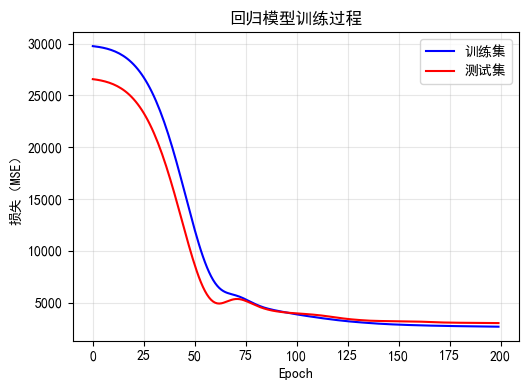

In [8]:
# 可视化训练过程
plt.figure(figsize=(10, 4))

# 训练损失
plt.subplot(1, 2, 1)
plt.plot(train_losses_reg, label='训练集', color='blue')
plt.plot(test_losses_reg, label='测试集', color='red')
plt.xlabel('Epoch')
plt.ylabel('损失（MSE）')
plt.title('回归模型训练过程')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [9]:
# 评估回归模型

regression_model.eval()
with torch.no_grad():
    y_pred_reg_test = regression_model(X_test_tensor).numpy()

# 计算评估指标
mse_reg = mean_squared_error(y_reg_test, y_pred_reg_test)
r2_reg = r2_score(y_reg_test, y_pred_reg_test)

print("回归模型评估结果：")
print(f"均方误差（MSE）: {mse_reg:.2f}")
print(f"R²分数: {r2_reg:.4f} = {r2_reg*100:.2f}%")

# 查看预测示例
print("\n预测示例（测试集前5名患者）：")
print("真实值 vs 预测值")
for i in range(5):
    print(f"患者{i+1}: {y_reg_test[i]:.1f} vs {y_pred_reg_test[i][0]:.1f} (误差: {abs(y_reg_test[i]-y_pred_reg_test[i][0]):.1f}")

回归模型评估结果：
均方误差（MSE）: 3024.04
R²分数: 0.4292 = 42.92%

预测示例（测试集前5名患者）：
真实值 vs 预测值
患者1: 219.0 vs 163.0 (误差: 56.0
患者2: 70.0 vs 203.4 (误差: 133.4
患者3: 202.0 vs 171.3 (误差: 30.7
患者4: 230.0 vs 314.4 (误差: 84.4
患者5: 111.0 vs 106.0 (误差: 5.0


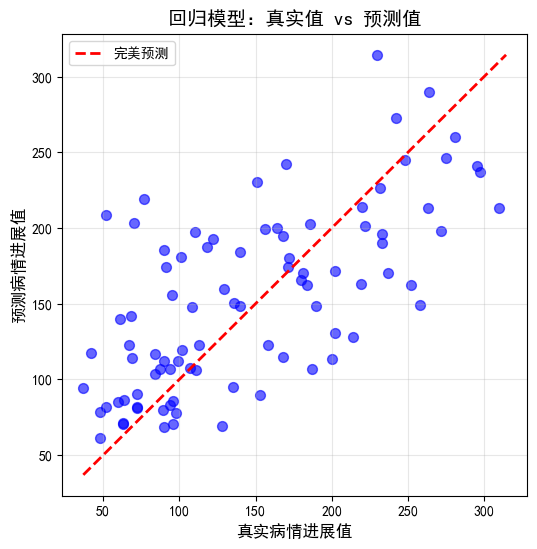


模型质量评价：
○ 模型表现中等，有一定的预测能力


In [10]:
# 可视化真实值 vs 预测值
plt.figure(figsize=(6, 6))
plt.scatter(y_reg_test, y_pred_reg_test, color='blue', alpha=0.6, s=50)

# 绘制完美预测线
min_val = min(y_reg_test.min(), y_pred_reg_test.min())
max_val = max(y_reg_test.max(), y_pred_reg_test.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='完美预测')

plt.xlabel('真实病情进展值', fontsize=12)
plt.ylabel('预测病情进展值', fontsize=12)
plt.title('回归模型：真实值 vs 预测值', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 打印模型质量评价
print("\n模型质量评价：")
if r2_reg > 0.5:
    print("✓ 模型表现良好，能够解释大部分变异")
elif r2_reg > 0.3:
    print("○ 模型表现中等，有一定的预测能力")
else:
    print("✗ 模型表现较差，需要改进")

## **8. 训练分类模型**

### **配置分类模型训练**

**分类任务的关键区别**：
- **损失函数**：使用二元交叉熵（Binary Cross-Entropy）而不是MSE
- **输出**：Sigmoid输出0-1之间的概率值
- **评估**：使用准确率（Accuracy）

In [11]:
# TODO: 定义损失函数
# 提示：使用 nn.BCELoss()
criterion_cls = nn.BCELoss()

# TODO: 定义优化器
# 提示：使用 optim.Adam，学习率设为0.001
optimizer_cls = optim.Adam(classification_model.parameters(), lr=0.001)

# 训练参数
num_epochs_cls = 400

print("分类模型训练配置完成！")
print(f"损失函数: 二元交叉熵（Binary Cross-Entropy）")
print(f"优化器: Adam (学习率=0.005)")
print(f"训练轮数: {num_epochs_cls}")

分类模型训练配置完成！
损失函数: 二元交叉熵（Binary Cross-Entropy）
优化器: Adam (学习率=0.005)
训练轮数: 400


In [12]:
# 训练分类模型
train_losses_cls = []
train_accuracies_cls = []
test_losses_cls = []
test_accuracies_cls = []

for epoch in range(num_epochs_cls):
    # 训练模式
    classification_model.train()
    
    # 前向传播
    outputs = classification_model(X_train_tensor)
    loss = criterion_cls(outputs, y_cls_train_tensor)
    
    # 计算训练准确率
    train_pred = (outputs > 0.5).float()
    train_accuracy = (train_pred == y_cls_train_tensor).float().mean()
    
    # TODO: 梯度清零、反向传播、更新参数
    optimizer_cls.zero_grad()
    loss.backward()
    optimizer_cls.step()
    
    # 记录训练损失和准确率
    train_losses_cls.append(loss.item())
    train_accuracies_cls.append(train_accuracy.item())
    
    # 在测试集上评估
    classification_model.eval()
    with torch.no_grad():
        test_outputs = classification_model(X_test_tensor)
        test_loss = criterion_cls(test_outputs, y_cls_test_tensor)
        test_pred = (test_outputs > 0.5).float()
        test_accuracy = (test_pred == y_cls_test_tensor).float().mean()
        test_losses_cls.append(test_loss.item())
        test_accuracies_cls.append(test_accuracy.item())
    
    # 打印训练进度
    if (epoch + 1) % 20 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs_cls}], Train Loss: {loss.item():.4f}, Train Acc: {train_accuracy*100:.2f}%, Test Acc: {test_accuracy*100:.2f}%')

print("\n分类模型训练完成！")

Epoch [20/400], Train Loss: 0.6861, Train Acc: 54.67%, Test Acc: 55.06%
Epoch [40/400], Train Loss: 0.6697, Train Acc: 54.67%, Test Acc: 55.06%
Epoch [60/400], Train Loss: 0.6457, Train Acc: 55.52%, Test Acc: 55.06%
Epoch [80/400], Train Loss: 0.6095, Train Acc: 63.46%, Test Acc: 65.17%
Epoch [100/400], Train Loss: 0.5654, Train Acc: 73.37%, Test Acc: 71.91%
Epoch [120/400], Train Loss: 0.5284, Train Acc: 73.65%, Test Acc: 73.03%
Epoch [140/400], Train Loss: 0.5019, Train Acc: 74.22%, Test Acc: 74.16%
Epoch [160/400], Train Loss: 0.4826, Train Acc: 74.50%, Test Acc: 73.03%
Epoch [180/400], Train Loss: 0.4698, Train Acc: 75.64%, Test Acc: 75.28%
Epoch [200/400], Train Loss: 0.4606, Train Acc: 76.20%, Test Acc: 75.28%
Epoch [220/400], Train Loss: 0.4535, Train Acc: 77.90%, Test Acc: 75.28%
Epoch [240/400], Train Loss: 0.4472, Train Acc: 77.62%, Test Acc: 74.16%
Epoch [260/400], Train Loss: 0.4414, Train Acc: 78.19%, Test Acc: 74.16%
Epoch [280/400], Train Loss: 0.4363, Train Acc: 79.04%,

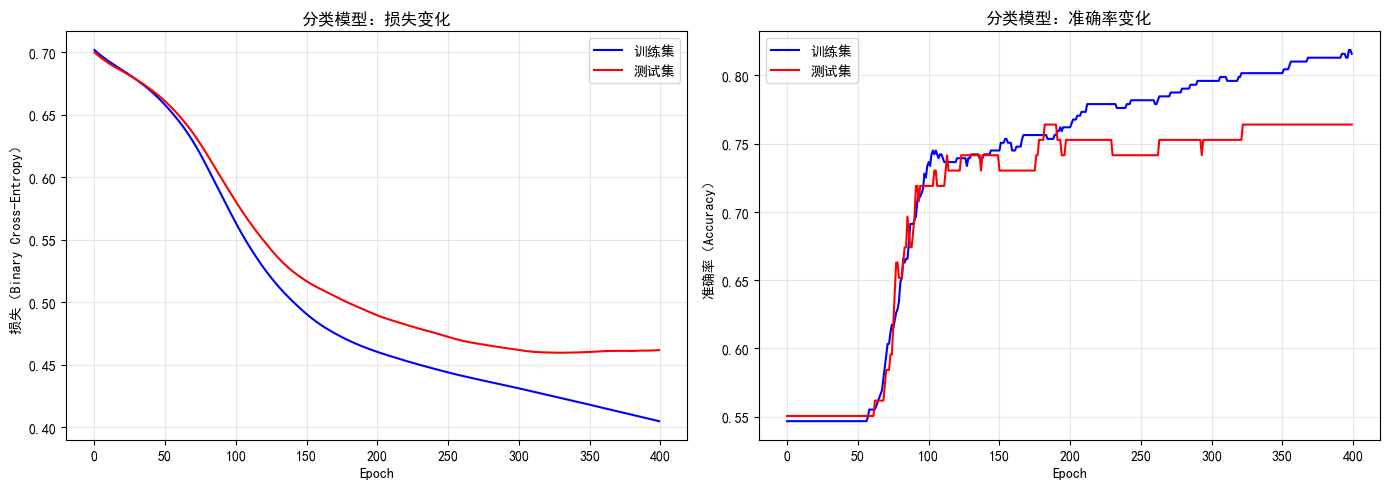

In [13]:
# 可视化分类模型训练过程
plt.figure(figsize=(14, 5))

# 损失变化
plt.subplot(1, 2, 1)
plt.plot(train_losses_cls, label='训练集', color='blue')
plt.plot(test_losses_cls, label='测试集', color='red')
plt.xlabel('Epoch')
plt.ylabel('损失（Binary Cross-Entropy）')
plt.title('分类模型：损失变化')
plt.legend()
plt.grid(True, alpha=0.3)

# 准确率变化
plt.subplot(1, 2, 2)
plt.plot(train_accuracies_cls, label='训练集', color='blue')
plt.plot(test_accuracies_cls, label='测试集', color='red')
plt.xlabel('Epoch')
plt.ylabel('准确率（Accuracy）')
plt.title('分类模型：准确率变化')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [14]:
# 评估分类模型
classification_model.eval()
with torch.no_grad():
    y_pred_cls_prob = classification_model(X_test_tensor).numpy()
    y_pred_cls = (y_pred_cls_prob > 0.5).astype(int)

# 计算评估指标
accuracy_cls = accuracy_score(y_cls_test, y_pred_cls)
precision_cls = precision_score(y_cls_test, y_pred_cls)
recall_cls = recall_score(y_cls_test, y_pred_cls)
f1_cls = f1_score(y_cls_test, y_pred_cls)

print("分类模型评估结果：")
print(f"准确率: {accuracy_cls*100:.2f}%")
print(f"精确率: {precision_cls*100:.2f}%")
print(f"召回率: {recall_cls*100:.2f}%")
print(f"F1分数: {f1_cls:.4f}")

# 查看预测示例
print("\n预测示例（测试集前5名患者）：")
print("真实标签 | 预测概率 | 预测标签 | 是否正确")
print("-" * 50)
for i in range(5):
    true_label = "高风险" if y_cls_test[i] == 1 else "低风险"
    pred_label = "高风险" if y_pred_cls[i][0] == 1 else "低风险"
    correct = "✓" if y_cls_test[i] == y_pred_cls[i][0] else "✗"
    print(f"{true_label:^6} | {y_pred_cls_prob[i][0]:.4f} | {pred_label:^6} | {correct}")

# 打印模型质量评价
print("\n模型质量评价：")
if accuracy_cls > 0.8:
    print("✓ 模型表现优秀，准确率很高")
elif accuracy_cls > 0.7:
    print("○ 模型表现良好，有较好的分类能力")
else:
    print("✗ 模型表现一般，需要改进")

分类模型评估结果：
准确率: 76.40%
精确率: 74.36%
召回率: 72.50%
F1分数: 0.7342

预测示例（测试集前5名患者）：
真实标签 | 预测概率 | 预测标签 | 是否正确
--------------------------------------------------
 高风险   | 0.5463 |  高风险   | ✓
 低风险   | 0.7268 |  高风险   | ✗
 高风险   | 0.5947 |  高风险   | ✓
 高风险   | 0.9874 |  高风险   | ✓
 低风险   | 0.3183 |  低风险   | ✓

模型质量评价：
○ 模型表现良好，有较好的分类能力


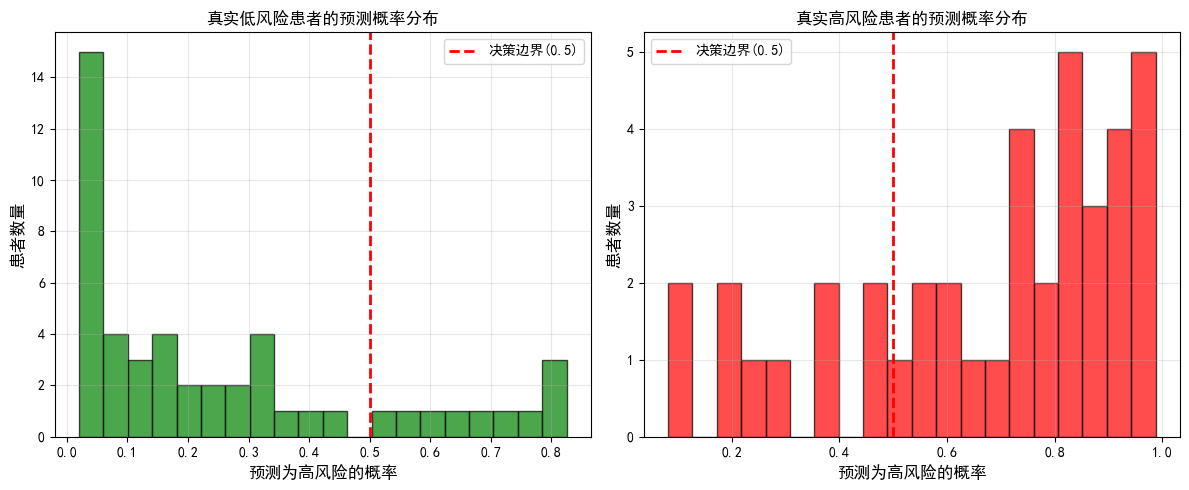

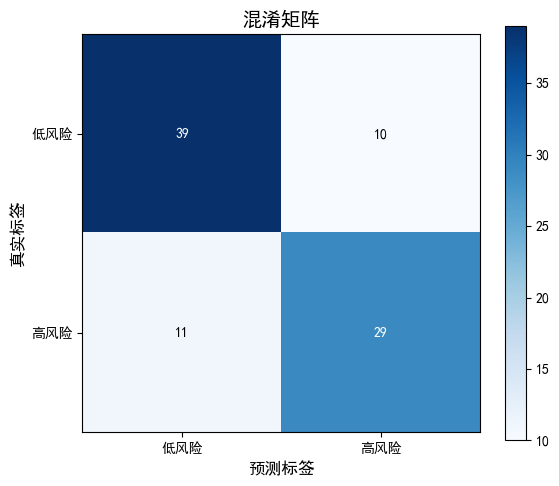

混淆矩阵解读：
真负例(TN): 39 - 正确识别为低风险的患者
假正例(FP): 10 - 错误判定为高风险的低风险患者（误诊）
假负例(FN): 11 - 错误判定为低风险的高风险患者（漏诊）
真正例(TP): 29 - 正确识别为高风险的患者


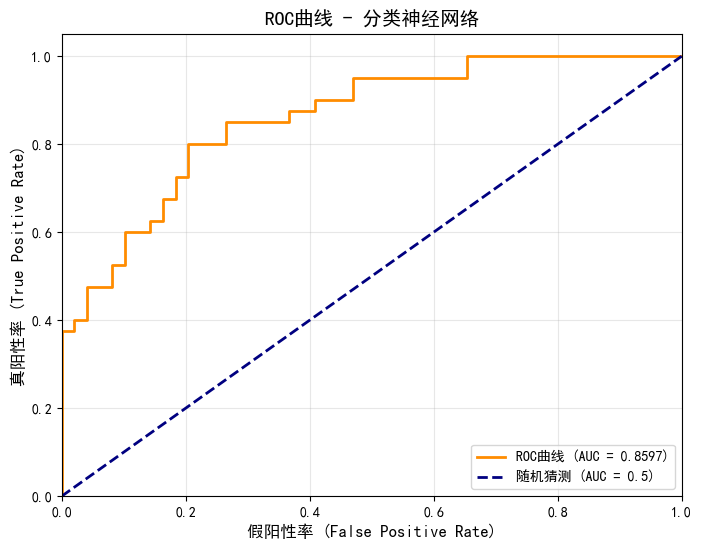


ROC曲线解读：
AUC值: 0.8597
- AUC = 0.5：模型没有预测能力（等同于随机猜测）
- AUC = 0.7-0.8：模型有一定预测能力
- AUC = 0.8-0.9：模型预测能力较好
- AUC = 0.9-1.0：模型预测能力很好


In [15]:
# 可视化预测概率分布
plt.figure(figsize=(12, 5))

# 真实低风险患者的预测概率
plt.subplot(1, 2, 1)
low_risk_probs = y_pred_cls_prob[y_cls_test == 0].flatten()
plt.hist(low_risk_probs, bins=20, color='green', alpha=0.7, edgecolor='black')
plt.axvline(x=0.5, color='red', linestyle='--', linewidth=2, label='决策边界(0.5)')
plt.xlabel('预测为高风险的概率', fontsize=12)
plt.ylabel('患者数量', fontsize=12)
plt.title('真实低风险患者的预测概率分布', fontsize=12, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

# 真实高风险患者的预测概率
plt.subplot(1, 2, 2)
high_risk_probs = y_pred_cls_prob[y_cls_test == 1].flatten()
plt.hist(high_risk_probs, bins=20, color='red', alpha=0.7, edgecolor='black')
plt.axvline(x=0.5, color='red', linestyle='--', linewidth=2, label='决策边界(0.5)')
plt.xlabel('预测为高风险的概率', fontsize=12)
plt.ylabel('患者数量', fontsize=12)
plt.title('真实高风险患者的预测概率分布', fontsize=12, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 混淆矩阵可视化
cm = confusion_matrix(y_cls_test, y_pred_cls)

plt.figure(figsize=(6, 5))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('混淆矩阵', fontsize=14, fontweight='bold')
plt.colorbar()
tick_marks = np.arange(2)
plt.xticks(tick_marks, ['低风险', '高风险'])
plt.yticks(tick_marks, ['低风险', '高风险'])
plt.ylabel('真实标签', fontsize=12)
plt.xlabel('预测标签', fontsize=12)

# 在混淆矩阵中添加数字
thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'),
                ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black")

plt.tight_layout()
plt.show()

print("混淆矩阵解读：")
print(f"真负例(TN): {cm[0,0]} - 正确识别为低风险的患者")
print(f"假正例(FP): {cm[0,1]} - 错误判定为高风险的低风险患者（误诊）")
print(f"假负例(FN): {cm[1,0]} - 错误判定为低风险的高风险患者（漏诊）")
print(f"真正例(TP): {cm[1,1]} - 正确识别为高风险的患者")

# ROC曲线可视化
fpr, tpr, thresholds = roc_curve(y_cls_test, y_pred_cls_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, 
         label=f'ROC曲线 (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--',
         label='随机猜测 (AUC = 0.5)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('假阳性率 (False Positive Rate)', fontsize=12)
plt.ylabel('真阳性率 (True Positive Rate)', fontsize=12)
plt.title('ROC曲线 - 分类神经网络', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=10)
plt.grid(True, alpha=0.3)
plt.show()

print(f"\nROC曲线解读：")
print(f"AUC值: {roc_auc:.4f}")
print("- AUC = 0.5：模型没有预测能力（等同于随机猜测）")
print("- AUC = 0.7-0.8：模型有一定预测能力")
print("- AUC = 0.8-0.9：模型预测能力较好")
print("- AUC = 0.9-1.0：模型预测能力很好")

## **9. 对比总结：回归 vs 分类**

让我们总结一下神经网络在两个任务上的差异：

In [16]:
# 打印对比总结
print("="*60)
print("回归任务 vs 分类任务对比总结")
print("="*60)

print("\n【任务目标】")
print(f"回归任务: 预测糖尿病病情进展数值 (范围: {y_regression.min():.0f}-{y_regression.max():.0f})")
print(f"分类任务: 判断患者是高风险还是低风险 (阈值: {threshold})")

print("\n【神经网络结构】")
print(f"回归网络: 输入层(10) → 隐藏层1(16) → 隐藏层2(8) → 输出层(1)")
print(f"分类网络: 输入层(10) → 隐藏层1(16) → 隐藏层2(8) → 输出层(1)")
print("注意：结构相同，只是输出层的激活函数不同！")

print("\n【关键区别】")
print("回归任务:")
print("  - 输出层激活函数: 无")
print("  - 损失函数: MSE (均方误差)")
print("  - 输出范围: 任意实数")
print("  - 评估指标: MSE, R²")
print("  - 应用: 预测具体数值")

print("\n分类任务:")
print("  - 输出层激活函数: Sigmoid")
print("  - 损失函数: BCE (二元交叉熵)")
print("  - 输出范围: 0-1 (概率)")
print("  - 评估指标: Accuracy, Precision, Recall, F1, AUC")
print("  - 应用: 分类判别")

print("\n【模型性能】")
print("回归任务:")
print(f"  - 均方误差（MSE）: {mse_reg:.2f}")
print(f"  - R²分数: {r2_reg:.4f} ({r2_reg*100:.2f}%)")

print("\n分类任务:")
print(f"  - 准确率: {accuracy_cls:.4f} ({accuracy_cls*100:.2f}%)")
print(f"  - 精确率: {precision_cls:.4f} ({precision_cls*100:.2f}%)")
print(f"  - 召回率: {recall_cls:.4f} ({recall_cls*100:.2f}%)")
print(f"  - F1分数: {f1_cls:.4f}")
print(f"  - AUC值: {roc_auc:.4f}")

print("\n【医学应用】")
print("回归任务应用:")
print("  - 预测病情进展程度")
print("  - 预测住院天数")
print("  - 预测治疗费用")

print("\n分类任务应用:")
print("  - 疾病诊断")
print("  - 风险分层")
print("  - 是否需要进一步检查")

print("="*60)

回归任务 vs 分类任务对比总结

【任务目标】
回归任务: 预测糖尿病病情进展数值 (范围: 25-346)
分类任务: 判断患者是高风险还是低风险 (阈值: 150)

【神经网络结构】
回归网络: 输入层(10) → 隐藏层1(16) → 隐藏层2(8) → 输出层(1)
分类网络: 输入层(10) → 隐藏层1(16) → 隐藏层2(8) → 输出层(1)
注意：结构相同，只是输出层的激活函数不同！

【关键区别】
回归任务:
  - 输出层激活函数: 无
  - 损失函数: MSE (均方误差)
  - 输出范围: 任意实数
  - 评估指标: MSE, R²
  - 应用: 预测具体数值

分类任务:
  - 输出层激活函数: Sigmoid
  - 损失函数: BCE (二元交叉熵)
  - 输出范围: 0-1 (概率)
  - 评估指标: Accuracy, Precision, Recall, F1, AUC
  - 应用: 分类判别

【模型性能】
回归任务:
  - 均方误差（MSE）: 3024.04
  - R²分数: 0.4292 (42.92%)

分类任务:
  - 准确率: 0.7640 (76.40%)
  - 精确率: 0.7436 (74.36%)
  - 召回率: 0.7250 (72.50%)
  - F1分数: 0.7342
  - AUC值: 0.8597

【医学应用】
回归任务应用:
  - 预测病情进展程度
  - 预测住院天数
  - 预测治疗费用

分类任务应用:
  - 疾病诊断
  - 风险分层
  - 是否需要进一步检查


## **10. 实践总结**

### **今天我们学到了什么**

**神经网络的核心概念**：
- 神经网络是模仿人脑的计算模型
- 由输入层、隐藏层、输出层组成
- 通过前向传播、损失计算、反向传播、参数更新来学习

**神经网络实现步骤**：
1. 定义网络结构（层数、神经元数量）
2. 定义损失函数（MSE或BCE）
3. 定义优化器（如Adam）
4. 编写训练循环（前向、计算损失、反向、更新）
5. 评估模型性能

**回归 vs 分类**：
- 回归：预测连续值，输出层无激活函数，用MSE
- 分类：预测类别，输出层用Sigmoid，用BCE
- 网络结构可以相同，只需改变输出层和损失函数

**神经网络 vs 传统机器学习**：
- 神经网络：更强大，能学习复杂关系，但需要更多数据和计算
- 传统机器学习：更简单，更可解释，适合简单任务

## **11. 课后练习**

### **思考题**

1. 如果我们想预测患者的"住院天数"，应该用回归还是分类？为什么？

2. 如果模型的训练集准确率是95%，但测试集准确率只有60%，这是什么问题？可能的原因是什么？

3. 在本例中，我们将病情进展 > 150 定义为高风险。如果将阈值改为 100 或 200，会对分类结果有什么影响？

4. 神经网络为什么需要激活函数？如果没有激活函数会怎样？

### **扩展练习（可选）**

1. **调整网络结构**：尝试增加或减少隐藏层的神经元数量，观察模型性能的变化。

2. **调整超参数**：尝试改变学习率（0.0001, 0.01）、训练轮数（50, 200），观察训练过程的变化（建议大家自己调整参数试一下，有可能会看到过拟合现象）。

3. **多分类任务**：将病情进展分成三个类别（低风险、中风险、高风险），设计一个多分类神经网络。

4. **与传统模型对比**：用 Logistic Regression 做同样的分类任务，对比神经网络的效果。

## **12. 总结**

**本节课重点**：
- 理解神经网络的基本原理和工作机制
- 学会用 PyTorch 构建和训练简单的神经网络
- 理解回归任务和分类任务在神经网络中的区别
- 理解神经网络训练的基本流程

**医学应用价值**：
- 神经网络可以处理复杂的医学数据
- 能够学习传统方法难以发现的模式
- 在医学影像、基因分析等领域有广泛应用

**下节课预告**：
- 卷积神经网络（CNN）：处理图像数据
- 应用场景：医学影像诊断（X光、CT、MRI）

---

**恭喜你完成了医学人工智能神经网络模型的实践！** 🎉

通过今天的练习，你已经掌握了：
- 神经网络的基本原理
- 用神经网络解决回归和分类问题
- 理解神经网络与传统机器学习的区别
- 理解神经网络在医学中的应用